# **2025 Machine Learning Term Project**

고려대학교 보건과학대학 바이오의공학부

2021250031 정예준

## Abstract

본 프로젝트에서는 UCI Bank Marketing 데이터셋의 'bank-full.csv'를 사용하여 고객의 기본 정보와 캠페인 이력 관련 정보를 바탕으로 고객의 정기 예금 가입 여부를 예측하는 이진 분류 모델을 구축하였다. 'yes' 라벨의 비율이 약 11.7%인 불균형 데이터임을 고려하여 성능 지표로는 `PR-AUC`를 주 지표, `ROC-AUC`와 `Accuracy`를 보조 지표로 사용하였다. 전처리 단계에서 모델에 적합하지 않은 feature를 제거하고 이상치를 처리한 후 기존의 feature들을 결합한 새로운 binary feature를 생성하였다. Categorical feature의 원핫 인코딩, Numerical feature의 로그 변환 및 스케일링은 파이프라인을 통해 수행하였다. 이후 `Logistic Regression`, `Support Vector Machine (SVM)`, `Random Forest`, `Gradient Boosting Classifier`, `Multi-Layer Perceptron (MLP)`의 5개 모델 모두에 대해 `Feature Selection`을 적용했을 때와 하지 않았을 때를 각각 5-fold CV로 비교 및 분석한 결과 `Feature Selection`을 적용하지 않은 `Gradient Boosting Classifier`가 3가지의 성능 지표 모두에서 가장 우수하고 균형 잡힌 성능을 보여 최종 후보 모델로 선정하였다. 해당 모델에 대해 Random Search와 Grid Search로 하이퍼파라미터 튜닝을 진행한 뒤 테스트셋에서 성능을 평가한 결과 `PR-AUC` 0.4334, `ROC-AUC` 0.8031, `ACC` 0.8944를 기록했다. 이는 목표값을 거의 충족하며 가입 가능성이 높은 고객을 효과적으로 선별할 수 있는 수준의 예측력을 확보한 것으로 해석할 수 있다.

## Phase 1

### 1. 데이터 선정

**본 프로젝트의 목표는 은행의 전화 마케팅 캠페인에서 고객의 정보를 바탕으로  고객이 정기 예금에 가입할 것인지 사전에 예측하는 것이다.**

In [ ]:
# 데이터 로드
import pandas as pd

bank = pd.read_csv("https://github.com/YejunJung-KU/Machine-Learning-Bank-Marketing/raw/main/bank-full.csv", sep=';', quotechar='"')

- Dataset source : UCI Machine Learning Repository - Bank Marketing https://archive.ics.uci.edu/dataset/222/bank+marketing
- License : Creative Commons Attribution 4.0 International (CC BY 4.0)
-> This allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given.

- 본 프로젝트는 UCI Machine Learning Repository의 Bank Marketing 데이터셋을 사용하였으며 해당 License에 따라 데이터를 저장한 후 활용하였다.
- UCI 사이트에서는 데이터가 웹페이지와 압축 파일 형태로 제공되어 있어서 직접 `read_csv()`로 불러오기 어려우므로, 저장 및 압축 해제 후 개인 Github의 public repository에 파일을 업로드한 뒤 해당 파일 URL 통해 데이터셋을 불러온다.
- 'bank-full.csv' 파일을 사용하였으며 파일의 각 행에서 모든 값에 큰따옴표(") 처리가 되어있고 세미콜론(;)으로 구분되어 있기 때문에 그것들을 제외하고 각각의 column으로 구분해서 읽어온다.

### 2. 문제 설정 및 전체적인 과제 설계

#### 2.1 기계학습 문제 설정

**기계학습 문제 설정**
- 나이, 직업, 계좌 잔액 등 고객의 기본 정보와 마지막 연락 시기, 총 연락 횟수, 이전 마케팅 캠페인 결과 등 캠페인 이력 관련 정보 등을 기계학습 모델의 input으로 사용한다.
- 각 고객이 정기 예금에 가입할 확률과 그에 따른 가입 여부(yes/no)를 예측하는 분류(classification) 모델을 학습한다.
- 이후 예측된 가입 확률이 높은 순으로 고객을 정렬하여 상위 구간의 고객에게 먼저 전화를 걸고 마케팅 예산을 우선적으로 배분함으로써 마케팅 효율을 향상시키는 방향으로 활용할 수 있다.

**기계학습 문제 정의**
- 본 문제는 input feature와 정답 label이 모두 주어진 지도 학습(supervised learning)이며 각 고객의 정기 예금 가입 여부(yes/no)를 예측하는 이진 분류(binary classification) 문제이다.

#### 2.2 모델의 성능 지표 선정

**PR-AUC**

- doc: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html

<img src="https://wiki.cloudfactory.com/media/pages/docs/mp-wiki/metrics/precision-recall-curve-and-auc-pr/6a33324886-1684131968/precision-recall-score-example.webp" width=500>

- `PR-AUC`는 Precision(정밀도)과 Recall(재현율)의 PR curve 아래 면적으로,  `Average Precision`이라고도 한다.
- Precision은 'yes'로 예측한 샘플 중에서 예측과 실제 모두 'yes'인 샘플의 비율이며, Recall은 실제 'yes'인 샘플 중에서 예측과 실제 모두 'yes'인 샘플의 비율이다.
- PR curve에서 곡선이 오른쪽 위로 향할수록 좋은 모델이다.
- 해당 데이터셋은 라벨이 'yes'인 비율이 약 11.7%인 불균형 데이터로 희귀한 'yes'를 잘 골라내는 것이 중요하기 때문에 양성 클래스에 초점을 맞춘 `PR-AUC`가 중요하다.
- ''yes'라고 예측한 상위 구간의 고객에게 전화했을 때 그 중 몇%의 고객이 실제로 가입할까?'라는 질문이 곧 Precision이며, 콜당 성공률을 올려야 마케팅 효율을 극대화할 수 있기에 `PR-AUC` 성능 지표가 문제의 목표에 가장 직접적으로 연결된다.
- 데이터셋의 양성 비율이 약 11.7%기 때문에 무작위로 상위 구간을 골라도 가입률이 11.7%이다. 따라서 모델이 의미 있으려면 이 값보다 확실히 높아야 하며, 모델이 상위 구간에서 2배에 가까운 가입률을 만들어줄 수 있는지 확인하고자 `PR-AUC`의 목표값을 0.20으로 설정한다.

**ROC-AUC**
- doc: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

<img src="https://i0.wp.com/sefiks.com/wp-content/uploads/2020/12/roc-curve-original.png?fit=726%2C576&ssl=1" width=500>

- `ROC-AUC`는 True Positive Rate(TPR=recall)과 False Positive Rate(FPR)의 Receiver Operating Characteristic(ROC) Curve 아래 면적이다.
- TPR은 실제 'yes'인 샘플 중에서 'yes'로 올바르게 예측한 샘플의 비율이며, FPR은 실제 'no'인 샘플 중에서 'yes'로 잘못 예측한 샘플의 비율이다.
- ROC curve에서 곡선이 왼쪽 위로 향할수록 좋은 모델이다.
- 해당 도메인에서 어떤 고객이 정기예금을 가입할 가능성이 더 높은가를 예측해서 정렬하고자 하기 때문에 `ROC-AUC`는 이 모델이 전반적으로 고객을 얼마나 잘 정렬하나 평가하는 데 적합하다.
- 고객을 가입 가능성이 높은 순서에 따라 정렬했을 때 실제 'yes'를 상위에 더 많이 올려놓을수록 `ROC-AUC`가 커지고, 이는 우선순위 리스트를 얼마나 잘 만드는지 평가하며 상위 구간에서 콜당 성공률을 올리고자 하는 문제의 목표와 일치한다.
- `ROC-AUC` 값이 0.5면 완전 랜덤하다는 의미이고 0.7 이상은 되어야 쓸만한 성능을 가지고 있다고 말할 수 있기에 본 프로젝트에서는 `ROC-AUC`의 목표값을 0.75로 설정한다.

**Accuracy**
- doc: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

<img src="https://miro.medium.com/v2/0*xmCZW4fKl4SNmBAq" width=300>

- `Accuracy`는 전체 샘플 중에서 정답을 맞힌 비율로 직관적이고 가장 널리 쓰이는 평가 지표이다.
- 해당 데이터셋과 같은 불균형 데이터에서 단독으로 쓰면 위험하지만, 가장 직관적으로 이해할 수 있는 지표이기도 하고 `PR-AUC`, `ROC-AUC`와 함께 보조 설명용으로 유용하다.
- 전반적으로 맞힌 비율이므로 모델이 아예 엉뚱한 예측만 하지는 않는다는 최소한의 신뢰도를 검증할 수 있으며, 자세한 구조 분석까지는 못하지만 기본적인 분류기 성능을 체크하고 baseline과 비교한다는 목적에 부합한다.
- 본 프로젝트의 데이터셋은 'yes'가 약 11.7%, 'no'가 약 88.3%인 라벨을 갖고 있기 때문에 모델이 모든 고객을 'no'라고 예측해도 88.3%의 정확도가 나온다. 따라서 이 수치보다 향상된 것을 보여줘야 하기 때문에 `Accuracy`의 목표값을 0.90으로 설정한다.

## Phase 2

In [ ]:
# Essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, randint, uniform

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

# Model
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score

### 3. 데이터 탐색 및 시각화 분석 (EDA)

#### 3.1 데이터셋 살펴보기

In [ ]:
# 데이터셋 인스턴스 출력
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


각 행은 한 명의 고객에 대한 정보를 나타내며, Target class를 제외한 총 16개의 특징(feature) 목록은 다음과 같다.

Target class :
- `y`: categorical(nominal) -> 최종적으로 정기 예금을 가입했는지 여부. 'yes'면 가입, 'no'면 미가입.

Numerical feature :
- `age`: numerical(continuous) -> 고객 나이
- `balance`: numerical(continuous) -> 연간 평균 계좌 잔액 (유로)
- `day`: numerical(discrete) -> 마지막 연락 날짜 (일)
- `duration`: numerical(continuous) -> 마지막 통화 시간 (초)
- `campaign`: numerical(discrete) -> 이번 캠페인 동안 이 고객에게 한 연락 횟수 (마지막 연락 포함)
- `pdays`: numerical(discrete) -> 이전 캠페인에서 이 고객에게 마지막으로 연락한 후 지나간 일수 ('-1'이면 연락한 적 없음)
- `previous`: numerical(discrete) -> 이전 캠페인에서 이 고객에게 한 연락 횟수

Categorical feature :
- `job`: categorical(nominal) -> 직업 유형
- `marital`: categorical(nominal) -> 결혼 상태
- `education`: categorical(ordinal) -> 교육 수준
- `default`: categorical(nominal) -> 채무 불이행 (신용 불량) 상태
- `housing`: categorical(nominal) -> 주택 담보 대출 보유 여부
- `loan`: categorical(nominal) -> 개인 대출 보유 여부
- `contact`: categorical(nominal) -> 연락 통신 수단
- `month`: categorical(ordinal) -> 마지막 연락이 이루어진 월
- `poutcome`: categorical(nominal) -> 이전 마케팅 캠페인의 결과

In [ ]:
# 데이터셋 정보 요약
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# Numerical feature에 대한 최솟값/최댓값 확인
num_cols = bank.select_dtypes(include=["int64"]).columns
bank[num_cols].agg(["min", "max"])

,age,balance,day,duration,campaign,pdays,previous
min,18,-8019,1,0,1,-1,0
max,95,102127,31,4918,63,871,275


`info()`를 통해 데이터셋을 살펴보았다.
- 데이터셋에는 45211개의 인스턴스가 있다.
- 모든 feature가 45211개의 NULL이 아닌 값이 있으므로 결측치는 존재하지 않는다.
- Numerical feature 값에 대해 이상치를 확인하고자 최솟값과 최댓값을 확인한 결과 `balance`와 `pdays`에서 음수값이 발견되었으며 이는 이후 전처리에서 `np.log1p` 로그 변환을 적용한다면 문제가 되기에 모든 음수값들을 0으로 변환하는 등의 처리가 필요하다.
- 너무 큰 이상치는 이후 전처리에서 문제가 생길 수도 있기 때문에 최댓값을 확인해 보았고 그 결과 가장 큰 값이 102127로 큰 문제가 없음을 알 수 있다.

본 과제의 목적은 정기예금 가입 여부를 예측하는 이진 분류이므로 도메인 상식과 각 특징의 분포 등을 함께 고려한다. 먼저 도메인 상식에 따른 각 feature의 유용성에 대해 분석했을 때, 모델에 포함할 특징과 포함하지 않을 특징은 다음과 같다.
- `duration`은 통화가 끝난 뒤에야 알 수 있는 정보이기 때문에 실제 캠페인 전에 가입 여부를 예측하는 실전용 모델에서 사용할 수 없다고 판단해 모델에 포함하지 않는다.
- `duration`을 제외한 나머지 feature들은 저축이나 투자 등의 금융 도메인에서 중요한 역할을 하는 고객의 기본 정보거나, 본 task와 관련이 깊은 과거와 현재의 마케팅 정보이기 때문에 모두 모델에 포함한다.

#### 3.2 데이터 시각화

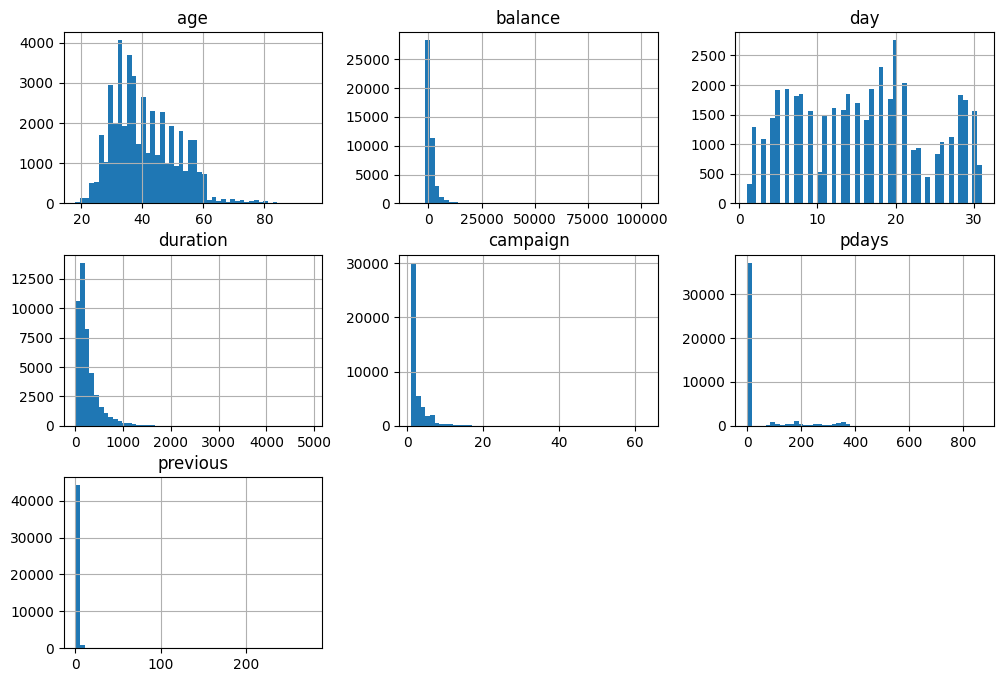

In [ ]:
# Numerical feature의 히스토그램 생성
bank_for_plot = bank.copy()

bank_for_plot.hist(bins=50, figsize=(12,8))
plt.show()

Numerical feature의 데이터 분포를 시각화하고 각 feature가 어떤 특징을 갖고 있는지, 수치적으로 모델에 사용하기 어려운 feature가 있는지 등에 대해 분석한다.
- 숫자형 특징(numerical feature) 7개에 대해서만 히스토그램이 생성된다.
- 사용하지 않기로 한 `duration`을 제외한 나머지 6개의 특징에 대해서만 분석한다.
- 여러 특징들은 서로 다른 범위를 가지고 있다.
- 롱테일 분포를 띄는 히스토그램의 경우 중앙값 오른쪽으로 길게 늘어나 있어 이는 일부 기계학습 모델이 데이터의 패턴을 학습하기 어렵게 만들 수 있다.
- `age`는 20대 후반~40대 초반에 봉우리가 있는 단봉형 분포이며 살짝 right-tail이 존재하지만 아주 심한 skew는 아니기 때문에 로그 변환까지는 필요 없을지라도 스케일링은 적용한다.
- `balance`, `campaign`, `pdays`, `previous`는 긴 right-tail을 가지고 있기 때문에 로그 변환 후 스케일링을 적용하는데, 이 중 `balance`와 `pdays`는 음수값이 존재하기에 이를 먼저 처리한다.
- `day`는 거의 균등 분포에 가까우며 skew도 없어서 변환은 필요 없고, 다른 feature들과 마찬가지로 스케일링만 진행한다.

이후 Categorical feature의 데이터 분포에 대해 하나씩 살펴본다.

Text(0.5, 1.0, 'Count plot of job for target variable y')

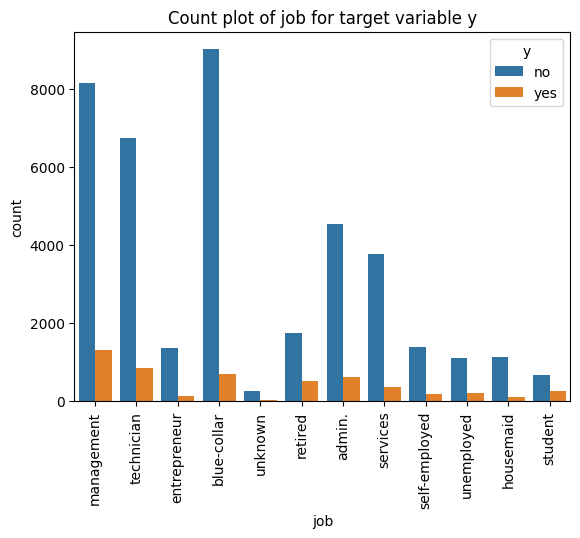

In [ ]:
# 'job'
sns.countplot(x=bank_for_plot['job'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.xticks(rotation=90)
plt.title('Count plot of job for target variable y')

Text(0.5, 1.0, 'Count plot of marital for target variable y')

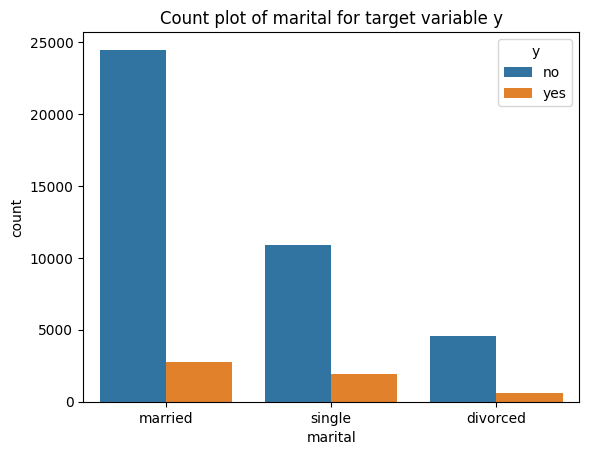

In [ ]:
# 'marital'
sns.countplot(x=bank_for_plot['marital'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of marital for target variable y')

Text(0.5, 1.0, 'Count plot of education for target variable y')

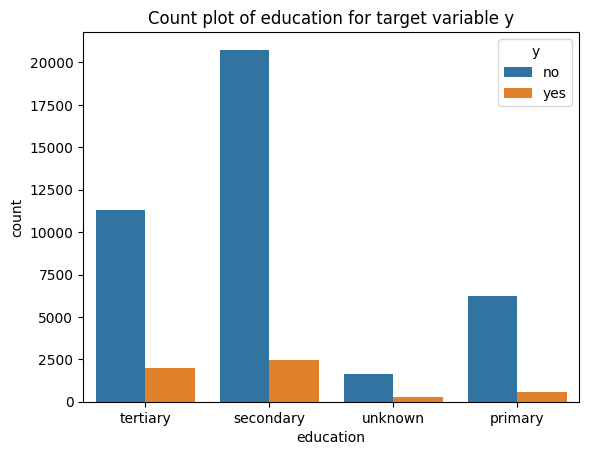

In [ ]:
# 'education'
sns.countplot(x=bank_for_plot['education'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of education for target variable y')

Text(0.5, 1.0, 'Count plot of default for target variable y')

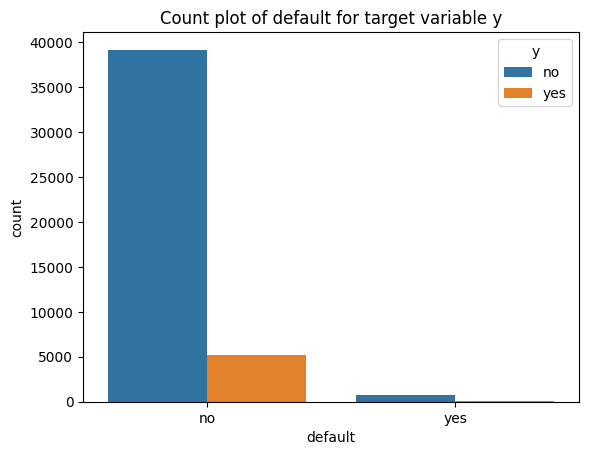

In [ ]:
# 'default'
sns.countplot(x=bank_for_plot['default'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of default for target variable y')

Text(0.5, 1.0, 'Count plot of housing for target variable y')

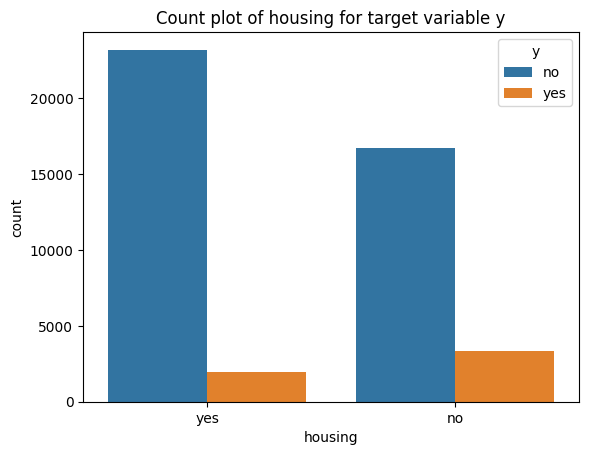

In [ ]:
# 'housing'
sns.countplot(x=bank_for_plot['housing'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of housing for target variable y')

Text(0.5, 1.0, 'Count plot of loan for target variable y')

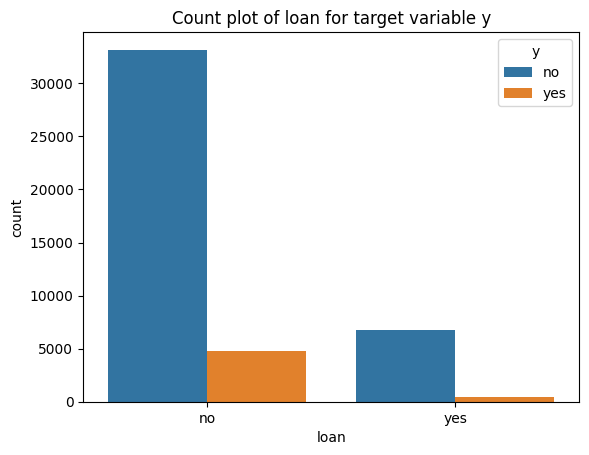

In [ ]:
# 'loan'
sns.countplot(x=bank_for_plot['loan'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of loan for target variable y')

Text(0.5, 1.0, 'Count plot of contact for target variable y')

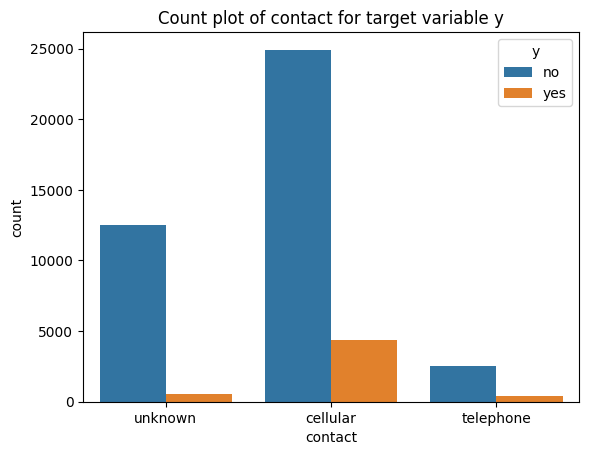

In [ ]:
# 'contact'
sns.countplot(x=bank_for_plot['contact'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of contact for target variable y')

Text(0.5, 1.0, 'Count plot of month for target variable y')

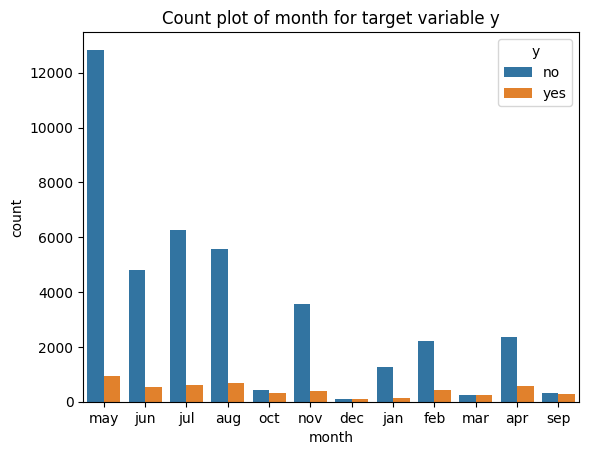

In [ ]:
# 'month'
sns.countplot(x=bank_for_plot['month'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of month for target variable y')

Text(0.5, 1.0, 'Count plot of poutcome for target variable y')

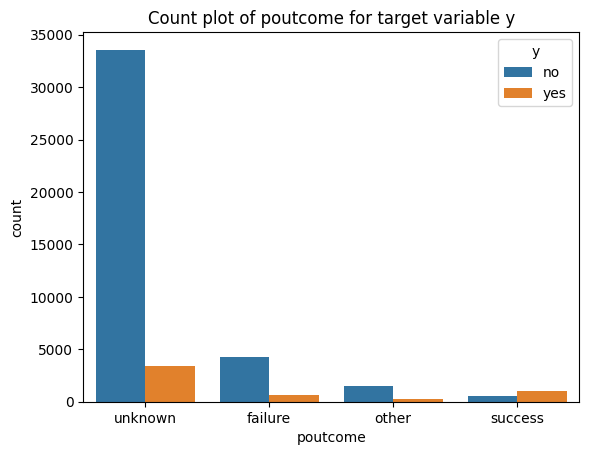

In [ ]:
# 'poutcome'
sns.countplot(x=bank_for_plot['poutcome'], data=bank_for_plot, hue=bank_for_plot['y'])
plt.title('Count plot of poutcome for target variable y')

In [ ]:
bank["y"].value_counts()

,count
y,
no,39922
yes,5289


Categorical feature의 countplot에서도 알 수 있었듯이, 해당 데이터셋은 라벨 `y`가 'no'에 크게 치우쳐져 있는 불균형 클래스 데이터셋임을 알 수 있다.

In [ ]:
bank_for_plot["default"].value_counts()

,count
default,
no,44396
yes,815


- 라벨 `y`를 제외한 9개의 Categorical feature에 대한 countplot을 출력해보았다.
- 대부분의 feature에서 큰 문제가 없지만 `default` 특징의 경우 그래프에서 'no'에 크게 치우쳐져 있음을 확인하였고 `value_counts()` 메소드로 확인해본 결과 'no'와 'yes'의 비율이 약 98%와 2%인 것을 알 수 있다. 이렇게 한쪽에 극단적으로 치우친 경우 모델의 기능에 악영향을 끼칠 가능성이 존재한다.
- 하지만 이러한 분포 특성만으로 적합하지 않다고 판단해 feature를 사전에 제거한다면 임의적 판단이 될 수 있기에 일단 즉시 제외하지는 않고 후보 feature로 유지한다.
- 이후 `Feature Selection` 기법을 적용하였을 때 feature의 유효성이 낮게 평가되거나 모델 성능에 부정적 영향을 끼치는 것이 보이면 그때 최종적으로 제거 여부를 결정한다.

#### 3.3 feature 간 상관관계

각 feature별로 어떤 전처리 파이프라인을 따를 것인지에 대한 결정을 하기 전에 feature 간 상관관계를 먼저 분석해본다.

In [ ]:
# 'pdays' = -1 인스턴스 개수
bank["pdays"].value_counts()[-1]

np.int64(36954)

In [ ]:
# 'previous' = 0 인스턴스 개수
bank["previous"].value_counts()[0]

np.int64(36954)

- `pdays`는 이전 캠페인에서 이 고객에게 마지막으로 연락한 후 지나간 일수로 '-1'이면 연락한 적 없음을 의미하고, `previous`는 이전 캠페인에서 이 고객에게 한 연락 횟수로 '0'이면 연락한 적 없음을 의미한다.
- 위의 두 경우는 의미적으로 같지만 `value_counts()` 메소드로 확인해봤을 때도 같은 값이 나오는 것을 확인하였다.
- 두 변수는 큰 연관성을 갖고 있기에 두 가지 다 존재할 필요는 없으며 위의 데이터 시각화 결과 `pdays`는 -1에, `previous`는 0에 아주 크게 몰려있는 극단적인 feature에다 음수값도 갖고 있어 사용하기에 어렵다.
- 따라서 두 변수 대신에 '이전 캠페인에서 연락을 했었는지 여부'에 대한 binary feature를 새로 만들고, 기존 2개의 변수는 사용하지 않는 것이 효과적이다.

이 외에도 다음과 같은 feature 간 상관관계가 존재할 수 있다.
- 주택 담보 대출 보유 여부인 `housing`과 개인 대출 보유 여부인 `loan`
- 교육 수준 `education`과 직업 유형 `job`, 그리고 평균 계좌 잔액 `balance`

하지만 이러한 feature들은 개별적으로도 유의미하고 모델의 기능에도 별 문제가 없기에 feature를 삭제하거나 이들을 이용해 새로운 feature를 만들지는 않는다.


#### 3.4 feature별 전처리 결정

따라서 feature별 적용할 전처리를 정리하면 다음과 같다.

Numerical feature :
- `duration`은 사용하지 않는다.
- `pdays`와 `previous` 대신에 '이전 캠페인에서 연락을 했었는지 여부'에 대한 binary feature `has_previous`를 새로 생성하고 기존 2개의 feature들은 사용하지 않는다.
- `balance`는 음수값이 존재하기에 모든 음수값들을 0으로 미리 만들어 놓는다.
- `balance`와 `campaign`은 로그 변환 후 스케일링을 적용한다.
- `age`와 `day`는 스케일링만 진행한다.

Categorical feature :
- 9개의 Categorical feature `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`에 원핫 인코딩을 적용한다.

Feature Selection:
- 위의 전처리가 모두 끝난 후 모델 입력 공간 전체에 대해 `Feature Selection`을 수행하여 예측에 기여도가 낮은 feature를 자동으로 제거한다.
- 이는 모델 학습 `Pipeline` 내부에 포함하는데, 데이터 누수를 방지하기 위해 CV의 각 fold에서 train 데이터로만 학습되도록 설계한다.

각 전처리 방법을 적용하는 이유는 앞선 데이터 탐색과 시각화를 진행하는 동안 설명되어 있으며, 각각의 기술적인 원리 및 세부 설명은 다음 섹션에 작성하였다.

### 4. 데이터 전처리

In [ ]:
# 원본 데이터셋은 그대로 유지하고, 복사본으로 작업
bank_copy = bank.copy()

#### 4.1 이상치 처리

In [ ]:
# 사용하지 않을 feature 제거
bank_copy = bank_copy.drop(columns=["duration"])

- `duration` feature의 경우 임의로 제거한 것이 아니라, 도메인 상식에 따른 feature의 유용성을 분석해봤을 때 실전용 모델에서 사용할 수 없다고 판단해 모델에 포함하지 않는 것이다.
- 이는 통화가 끝난 뒤에야 알 수 있는 정보이기 때문에 실제 캠페인 전에 가입 여부를 예측하는 목적인 경우 데이터 누수가 발생할 수 있기 때문에 이를 방지하기 위해 제외한다.

In [ ]:
# 'duration' feature가 제거된 것을 확인
bank_copy.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [ ]:
# 'balance' feature에 음수값이 있다는 것을 확인
bank_copy["balance"].min()

-8019

In [ ]:
# 'balance' feature의 모든 음수값을 0으로 치환 후 확인
bank_copy.loc[bank_copy["balance"] <= -1, "balance"] = 0
bank_copy["balance"].min()

0

#### 4.2 새로운 feature 생성

In [ ]:
# 새로운 feature 'has_previous' 생성
bank_copy['has_previous'] = (bank_copy['previous'] > 0).astype(int)

In [ ]:
# 'pdays'와 'previous' 제거
bank_copy = bank_copy.drop(columns=["pdays", "previous"])

In [ ]:
# 새로운 특징 생성 여부 및 현재 데이터셋 상태 확인
bank_copy.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,poutcome,y,has_previous
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,unknown,no,0


- 여기까지 사용하지 않을 feature를 제거하고, 이상치를 처리하였으며, 새로운 feature를 생성하였다.
- 이제 데이터 복사본을 생성하고 target label `y`를 분리한다.
- 이후 `Scikit-learn`의 `train_test_split()` 메소드를 이용하여 train data와 test data를 분리한다.
- 단, 해당 데이터셋은 불균형 데이터이기 때문에 target label의 비율을 train과 test 둘 다에서 원래 비율과 비슷하게 유지해 주는 `stratify=y` 옵션을 사용한다.

In [ ]:
X = bank_copy.drop("y", axis=1)
y = bank_copy["y"].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

#### 4.3 범주형 feature 변환

**이 단계부터 파이프라인을 통한 간단한 전처리가 가능하기 때문에 각 전처리 단계의 원리 및 방법만 확인하고. 이후 파이프라인을 통한 전처리에서 한꺼번에 처리한다.**

One-hot encoding
- `Scikit-learn`의 `OneHotEncoder()` 메소드를 사용한다.
- Categorical feature에서 각 category마다 하나의 binary feature가 되도록 변환한다.
- 그 category에 해당하는 경우 해당 feature 하나만 1이고 나머지는 0인 방식이다.
- 새로 생성된 특징들을 더미 변수(dummy variable)라고도 한다.

앞선 데이터 시각화 섹션에서 모든 Categorical feature에서 각각 어떤 category를 가지고 있는지는 미리 확인하였기 때문에 그 중 2개만 예시를 들어 One-hot encoding의 원리를 확인한다.

In [ ]:
# 복사본 생성
X_train_for_ohe = X_train.copy()

In [ ]:
# 'education'과 'loan' feature로 One-hot encoding 작동 확인
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

eduloan_ohe = ohe.fit_transform(X_train_for_ohe[["education","loan"]])
ohe_cols = ohe.get_feature_names_out(["education","loan"])
eduloan_ohe = pd.DataFrame(eduloan_ohe, columns=ohe_cols, index=X_train_for_ohe.index)

In [ ]:
# 인코더의 categories_ 인스턴스 변수를 사용하여 카테고리 목록 출력
ohe.categories_

[array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object),
 array(['no', 'yes'], dtype=object)]

In [ ]:
# 'education'과 'loan' feature에 대한 One-hot encoding 결과 확인
eduloan_ohe.head()

,education_primary,education_secondary,education_tertiary,education_unknown,loan_no,loan_yes
41401,0.0,1.0,0.0,0.0,1.0,0.0
8519,0.0,0.0,1.0,0.0,1.0,0.0
13832,1.0,0.0,0.0,0.0,1.0,0.0
16872,0.0,1.0,0.0,0.0,1.0,0.0
18766,0.0,1.0,0.0,0.0,1.0,0.0


#### 4.4 분포 변환

Long-tail 분포 변환

- 특정 feature의 분포가 Long-tail 분포를 가질 때 표준화는 대부분의 값을 작은 범위로 압축하게 되기 때문에 학습이 원활하게 이루어지지 않을 수 있다.
- 따라서 feature를 스케일링하기 전에 Long-tail 분포를 줄이기 위한 변환을 먼저 적용하고 가능하다면 분포를 대략 대칭적으로 만드는 것이 좋다.
- 구체적으로 로그 변환을 적용한다.
- `Scikit-learn`의 `FunctionTransformer(np.log1p)` 메소드를 사용한다.

앞선 섹션에서 로그 변환이 필요한 feature는 `balance`와 `campaign`임을 미리 파악하였으며, 이 feature들에 대해 로그 변환의 원리를 파악해본다.

In [ ]:
# 복사본 생성
X_train_for_log = X_train.copy()

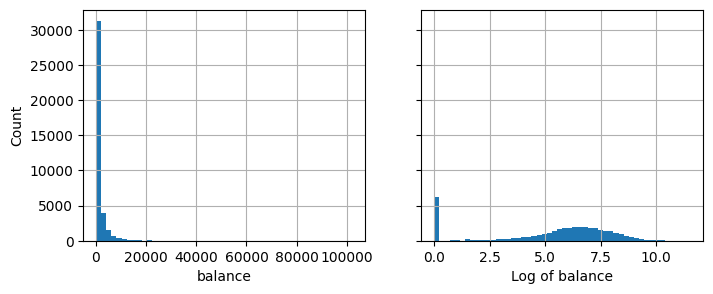

In [ ]:
# 'balance'에 로그를 적용했을 때 얼마나 개선되는지 확인
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
X_train_for_log["balance"].hist(ax=axs[0], bins=50)
X_train_for_log["balance"].apply(np.log1p).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("balance")
axs[1].set_xlabel("Log of balance")
axs[0].set_ylabel("Count")
plt.show()

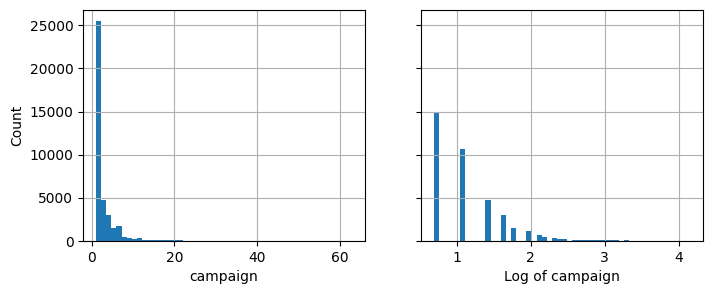

In [ ]:
# 'campaign'에 로그를 적용했을 때 얼마나 개선되는지 확인
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
X_train_for_log["campaign"].hist(ax=axs[0], bins=50)
X_train_for_log["campaign"].apply(np.log1p).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("campaign")
axs[1].set_xlabel("Log of campaign")
axs[0].set_ylabel("Count")
plt.show()

#### 4.5 feature 스케일링

표준화(Standardization)
- `Scikit-learn`의 `StandardScaler()` 메소드를 사용한다.
- 평균값을 빼서 평균이 0인 값을 만들고, 그 후에 표준 편차로 나누어 표준 편차가 1이 되도록 조정한다.
- Min-max scaling과 달리, 표준화는 값을 특정 범위로 제한하지 않는다.
- 표준화는 이상치에 영향을 덜 받는다.

앞선 섹션에서 표준화 스케일링이 필요한 feature에는 어떤 것들이 있는지 미리 확인하였으며, 그 중 `age` feature로 표준화의 원리를 파악해본다.

In [ ]:
# 복사본 생성
X_train_for_scale = X_train.copy()

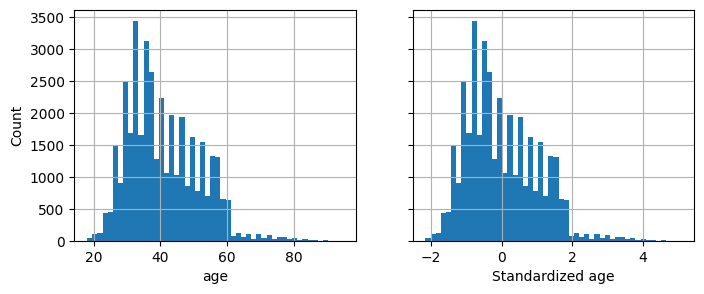

In [ ]:
# 'age' feature에 표준화 적용
std_scaler = StandardScaler()
age_scaled = std_scaler.fit_transform(X_train_for_scale[["age"]])
age_scaled = pd.Series(age_scaled.ravel(), index=X_train_for_scale.index)

# 표준화된 'age' feature 시각화
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
X_train_for_scale["age"].hist(ax=axs[0], bins=50)
age_scaled.hist(ax=axs[1], bins=50)
axs[0].set_xlabel("age")
axs[1].set_xlabel("Standardized age")
axs[0].set_ylabel("Count")
plt.show()

#### 4.6 파이프라인을 통한 전처리

`Scikit-learn`의 파이프라인

- 올바른 순서로 실행되어야 하는 많은 데이터 변환 단계를 처리할 수 있도록 `Scikit-learn`은 `Pipeline` 클래스를 제공한다.
- `Pipeline` 생성자는 이름/estimator 쌍(튜플)의 리스트를 받아 변환 단계의 순서를 정의한다.
 - 이름은 중복되지 않고 이중 밑줄(`__`)이 포함되지 않으면 무엇이든 상관없다.
 - 이름들은 하이퍼파라미터 튜닝을 때 유용하게 사용된다.

In [ ]:
# 현재 데이터 상태 확인
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,poutcome,has_previous
41401,44,admin.,married,secondary,no,764,yes,no,cellular,3,sep,1,failure,1
8519,36,technician,divorced,tertiary,no,1762,yes,no,unknown,3,jun,1,unknown,0
13832,51,blue-collar,divorced,primary,no,1236,yes,no,cellular,10,jul,1,unknown,0
16872,33,services,single,secondary,no,310,yes,no,cellular,25,jul,7,unknown,0
18766,42,technician,married,secondary,no,649,yes,no,telephone,31,jul,4,unknown,0


- 현재 `X_train`과 `X_test`는 사용하지 않을 feature 제거, 이상치 처리, 새로운 feature 생성까지 진행된 상태이다.
- 이후 범주형 feature 변환, 분포 변환, feature 스케일링 전처리는 `Pipeline`을 통해 진행한다.

In [ ]:
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
num_cols_logscale = ["balance", "campaign"]
num_cols_scale = ["age", "day"]

cat_pipe = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
num_logscale_pipe = Pipeline([
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])
num_scale_pipe = Pipeline([
    ("scaler", StandardScaler())
])

preprocessing = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num_ls", num_logscale_pipe, num_cols_logscale),
    ("num_s", num_scale_pipe, num_cols_scale)
], remainder="passthrough")

In [ ]:
# 전처리가 잘 진행되나 임시로 확인
X_for_pp = X_train.copy()
Xt = preprocessing.fit_transform(X_for_pp)
feat_names = preprocessing.get_feature_names_out(input_features=X_for_pp.columns)
Xt_df = pd.DataFrame(Xt, columns=feat_names, index=X_for_pp.index)
Xt_df.head()

,cat__job_admin.,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,cat__job_management,cat__job_retired,cat__job_self-employed,cat__job_services,cat__job_student,cat__job_technician,...,cat__month_sep,cat__poutcome_failure,cat__poutcome_other,cat__poutcome_success,cat__poutcome_unknown,num_ls__balance,num_ls__campaign,num_s__age,num_s__day,remainder__has_previous
41401,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.474772,-0.910084,0.291410,-1.537749,1.0
8519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.774252,-0.910084,-0.461715,-1.537749,0.0
13832,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.647154,-0.910084,0.950393,-0.696722,0.0
16872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.151909,1.801660,-0.744136,1.105479,0.0
18766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.416338,0.882281,0.103129,1.826359,0.0


In [ ]:
# 라벨 'y'의 yes/no를 1/0으로 변환
y_train = (y_train == "yes").astype(int)
y_test = (y_test == "yes").astype(int)

In [ ]:
# 1/0 수치형 라벨로 변환된 것 확인
y_train.head()

,y
41401,0
8519,0
13832,0
16872,0
18766,0


#### 4.7 Feature Selection

- 파이프라인을 이용한 전처리까지 모두 끝난 후 `Feature Selection`을 통해 예측에 기여도가 낮은 feature를 자동으로 제거하도록 한다.
- 단, 데이터 누수를 방지하기 위해 이후 `5. 모델 선정과 실험` 섹션에서 preprocessing-feature selection-model 학습을 하나의 Pipeline으로 구성하고 CV 각 fold에서 selector가 train fold에 대해서만 학습되도록 적용한다.

**따라서 본 섹션에서는 Feature Selection의 동작 원리 및 방법을 익히고 선택 결과가 어떻게 되는지 확인만 한 후, 실제 구현은 이후 모델 실험 파트에서 진행한다.**

In [ ]:
# 복사본 생성
X_train_for_fs = X_train.copy()
y_train_for_fs = y_train.copy()

**SelectFromModel**

- doc: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html#sklearn.feature_selection.SelectFromModel

- `SelectFromModel`은 학습된 모델이 제공하는 중요도 지표를 이용해 중요도가 낮은 feature를 제거하는 `Feature Selection` 방식이다. 이는 아래 모델들과 함께 사용할 수 있다.
  - 특징에 중요도(`coef_` 혹은 `feature_importances_`) attribute이 존재하는 모델
  - 훈련(fitting) 후 `importance_getter` callable 함수를 호출할 수 있는 모델
- 이에 해당되는 모델 중 L1 규제가 적용된 `Logistic Regression`을 selector의 estimator로 사용한다.
- L1 규제는 중요하지 않은 feature의 개수를 0에 가깝게 수축시키는 성질로 인해 희소한 선택을 유도하고 불필요한 feature를 자동으로 제거하는 데에 적합하다.
- 또한, 타깃 라벨 'y'의 분포가 불균형한 상태이기 때문에 selector 학습 시 `class_weight='balanced'`를 적용하여 안정성을 확보한다.
- threshold는 median으로 설정하여 selector를 학습시킨 뒤에 계수의 절댓값이 median 이상인 feature만을 선택하도록 한다.
- `SelectFromModel` 안에 있는 `Logistic Regression`은 입력이 모두 숫자여야 하므로 아직 Categorical feature가 그대로 있는 `X_train_for_fs`에 이전 섹션에서 구현한 전처리 파이프라인을 같이 이용하여 테스트 해본다.

In [ ]:
# SelectFromModel selector 정의
selector = SelectFromModel(estimator=LogisticRegression(penalty="l1", solver="saga",
                                                        class_weight="balanced",
                                                        max_iter=5000, random_state=42),
                           threshold="median")

# Pipeline을 이용한 Selector 학습
fs_demo_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector)
])

fs_demo_pipe.fit(X_train_for_fs, y_train_for_fs)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('num_ls',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['balance', 'campaign']),
                                                 ('num_s',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'day'])])),
                ('fs',
                 SelectFromModel(estimator=LogisticRegression(class_weight='balanced',
                                                              max_iter=5000,
                                                              penalty='l1',
                                                              random_state=42,
                                                              solver='saga'),
                                 threshold='median'))])

In [ ]:
X_train_for_fs.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,poutcome,has_previous
41401,44,admin.,married,secondary,no,764,yes,no,cellular,3,sep,1,failure,1
8519,36,technician,divorced,tertiary,no,1762,yes,no,unknown,3,jun,1,unknown,0
13832,51,blue-collar,divorced,primary,no,1236,yes,no,cellular,10,jul,1,unknown,0
16872,33,services,single,secondary,no,310,yes,no,cellular,25,jul,7,unknown,0
18766,42,technician,married,secondary,no,649,yes,no,telephone,31,jul,4,unknown,0


In [ ]:
# 선택된 feature 결과 확인
all_feature_names = fs_demo_pipe.named_steps["pre"].get_feature_names_out()

support = fs_demo_pipe.named_steps["fs"].get_support()
selected_feature_names = all_feature_names[support]

print("Selected:", support.sum(), "/", len(all_feature_names))
print(selected_feature_names)

Selected: 25 / 49
['cat__job_housemaid' 'cat__job_retired' 'cat__job_student'
 'cat__marital_married' 'cat__education_tertiary' 'cat__housing_no'
 'cat__housing_yes' 'cat__loan_no' 'cat__contact_cellular'
 'cat__contact_unknown' 'cat__month_aug' 'cat__month_dec' 'cat__month_feb'
 'cat__month_jan' 'cat__month_jul' 'cat__month_mar' 'cat__month_may'
 'cat__month_nov' 'cat__month_oct' 'cat__month_sep'
 'cat__poutcome_failure' 'cat__poutcome_success' 'num_ls__balance'
 'num_ls__campaign' 'remainder__has_previous']


In [ ]:
# Feature selection 이후 차원이 줄어든 것을 확인
X_before = fs_demo_pipe.named_steps["pre"].transform(X_train_for_fs)
X_after  = fs_demo_pipe.transform(X_train_for_fs)

print("Before FS (after preprocessing) shape:", X_before.shape)
print("After  FS shape:", X_after.shape)

Before FS (after preprocessing) shape: (38429, 49)
After  FS shape: (38429, 25)


- `SelectFromModel`이 선택한건 원핫 인코딩이 이루어진 후의 총 49개 feature 중에서 25개이다.
- 즉, 원핫 인코딩의 더미를 고려한 개수가 아니더라도 `job`, `marital`, `education`, `housing`, `loan`, `contact`, `month`, `poutcome`, `balance`, `campaign`, `has_previous` 총 11개의 원본 feature가 선택되어 남아있는 것을 확인할 수 있다.

### 5. 모델 선정과 실험

- 총 5개의 모델을 선정하여 실험을 진행한다.
- 각 모델을 train set에 대해 훈련하고 `2.2 모델의 성능 지표 선정`에서 정한 지표에 대해 k_fold CV 성능을 평가한다.
- 각 모델에 대하여 `Feature Selection` 기법을 적용하지 않았을 때와 적용하였을 때를 모두 실험하여 CV 성능 차이를 비교한다.
- 단, k-fold CV에서 매 fold마다 selector가 조금씩 다른 데이터로 fit 되기 때문에 선택되는 feature의 개수가 fold마다 달라질 수 있다.
- 따라서 모든 fold에서 원본 feature의 개수가 10개 이상으로 유지되는지 확인해본다.

In [ ]:
# Feature Selection 이후 남아있는 원본 feature의 개수 확인
def count_original_features_after_fs(fitted_pipe):
    all_names = fitted_pipe.named_steps["pre"].get_feature_names_out()
    support = fitted_pipe.named_steps["fs"].get_support()
    selected_names = all_names[support]
    originals = set()
    for n in selected_names:
        s = str(n)
        if "__" in s:
            _, rest = s.split("__", 1)
        else:
            rest = s
        if "__" in rest:
            rest = rest.split("__")[-1]
        original = rest.split("_", 1)[0]
        originals.add(original)

    return len(originals), sorted(originals)

In [ ]:
# 각 fold마다 원본 feature의 개수가 10개 이상 남아있는 것을 확인
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
selector = SelectFromModel(estimator=LogisticRegression(penalty="l1", solver="saga",
                                                        class_weight="balanced",
                                                        max_iter=5000, random_state=42),
                           threshold="median")

fold_counts = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    pipe = Pipeline([
        ("pre", preprocessing),
        ("fs", selector)
    ])
    pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])

    n_orig, orig_list = count_original_features_after_fs(pipe)
    fold_counts.append(n_orig)
    print(f"Fold {fold}: original features kept = {n_orig}")

Fold 1: original features kept = 10
Fold 2: original features kept = 10
Fold 3: original features kept = 10
Fold 4: original features kept = 10
Fold 5: original features kept = 10


- 이후 모델 성능을 평가할 때와 동일한 설정의 5-fold stratified CV split을 사용하여 테스트하였다.
- 동일한 cv 객체는 동일한 split을 만들어내기 때문에 해당 fold는 이후 모델 성능 평가에 사용된 fold와 동일하다.
- 각 fold에서 SelectFromModel 이후 남아있는 원본 feature 수는 10개로 유지됨을 확인하였다.

In [ ]:
# 각 fold마다 원본 feature의 개수가 10개 이상 남아있는 것을 확인
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
selector_rf = SelectFromModel(estimator=RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                               class_weight="balanced",
                                                               random_state=42, n_jobs=-1),
                              threshold="median")

fold_counts = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
    pipe = Pipeline([
        ("pre", preprocessing),
        ("fs", selector_rf)
    ])
    pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])

    n_orig, orig_list = count_original_features_after_fs(pipe)
    fold_counts.append(n_orig)
    print(f"Fold {fold}: original features kept = {n_orig}")

Fold 1: original features kept = 13
Fold 2: original features kept = 13
Fold 3: original features kept = 13
Fold 4: original features kept = 13
Fold 5: original features kept = 13


`SelectFromModel`의 estimator로 `Random Forest`를 사용했을 때도 각 fold에서 남아있는 원본 feature의 개수는 13개로 10개 이상 유지되는 것을 확인하였다.

#### 5.1 Logistic Regression

- doc: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

<img src="https://vitalflux.com/wp-content/uploads/2022/03/logistic-regression-model-3.png" width=650>

- `Logistic Regression`은 input feature들의 선형 결합으로 클래스에 해당할 확률을 직접 예측하는 방법이다.
- 가장 기본적인 linear classification model이라 baseline 성능 확인에 좋다.
- 어떤 feature들이 가입 확률을 높이고 낮추는지 각 feature의 weight을 통해 직접 해석할 수 있다.
- 원핫 인코딩 후 스케일링 전처리를 했으니 `Logistic Regression` 세팅에 적합하고 `class_weight='balanced'` 옵션으로 불균형도 어느 정도 보정할 수 있기에 해당 데이터셋에 적합하다.

In [ ]:
# Logistic Regression (without feature selection)
lr = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                        solver="lbfgs", max_iter=500, random_state=42)
lr_pipe = Pipeline([
    ("pre", preprocessing),
    ("lr", lr)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_lr = cross_validate(lr_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_lr['test_pr'].mean():.4f} ± {cv_lr['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_lr['test_roc'].mean():.4f} ± {cv_lr['test_roc'].std():.4f}")
print(f"ACC: {cv_lr['test_acc'].mean():.4f} ± {cv_lr['test_acc'].std():.4f}")

PR-AUC  : 0.4108 ± 0.0205
ROC-AUC : 0.7699 ± 0.0092
ACC: 0.7556 ± 0.0048


- `Logistic Regression` 모델의 5-fold CV 성능은 `PR-AUC` 0.4108, `ROC-AUC` 0.7699, `ACC` 0.7556을 기록했다.
- 간단한 linear model임에도 `PR-AUC`와 `ROC-AUC`는 각각 기준치인 0.20과 0.75를 넘겼기 때문에 기본적인 분류 성능은 확보한 것으로 보인다.
- 하지만 `ACC`가 약 76%로 모두 'no'라고 예측하는 88%보다도 낮은 것으로 보아 전반적인 정답률보다는 'yes' 클래스를 구분하는 능력에 초점이 맞춰진 baseline 모델이라고 해석할 수 있다.

In [ ]:
# Logistic Regression (with feature selection)
selector = SelectFromModel(estimator=LogisticRegression(penalty="l1", solver="saga",
                                                        class_weight="balanced",
                                                        max_iter=5000, random_state=42),
                           threshold="median")
lr = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                        solver="lbfgs", max_iter=500, random_state=42)
lr_fs_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector),
    ("lr", lr)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_lr_fs = cross_validate(lr_fs_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_lr_fs['test_pr'].mean():.4f} ± {cv_lr_fs['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_lr_fs['test_roc'].mean():.4f} ± {cv_lr_fs['test_roc'].std():.4f}")
print(f"ACC: {cv_lr_fs['test_acc'].mean():.4f} ± {cv_lr_fs['test_acc'].std():.4f}")

PR-AUC  : 0.4092 ± 0.0204
ROC-AUC : 0.7689 ± 0.0092
ACC: 0.7558 ± 0.0046


- `Feature Selection`을 적용한 `Logistic Regression` 모델의 5-fold CV 성능은 `PR-AUC` 0.4092, `ROC-AUC` 0.7689, `ACC` 0.7558을 기록했다.
- `Feature Selection`을 적용하지 않은 결과와 비교했을 때, 전반적으로 성능 변화가 매우 미미한 것을 확인할 수 있다.
- 이는 본 데이터에서 `Logistic Regression`이 이미 규제화된 linear model이라 불필요한 특성에 덜 민감하고, 일부 원핫 더미가 제거되더라도 핵심 정보가 유지되었기에 성능이 거의 변하지 않은 것으로 보인다.

#### 5.2 Support Vector Machine (SVM)

- doc: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

<img src="https://static.packt-cdn.com/products/9781783555130/graphics/3547_03_07.jpg" width=600>

- hyperplane은 데이터를 나누는 경계선 혹은 면으로 이를 기준으로 데이터를 각 클래스에 분류하며, support Vector는 margin 경계에 닿는 input vector이다. 이때 margin은 분리 hyperplane과 각 클래스에서 가장 가까운 데이터 포인트들(support vector) 사이의 거리이다.
- `Support Vector Machine (SVM)`은 이 margin을 최대화하는 hyperplane을 찾아내어 데이터를 분류하며 이는 `Logistic Regression`보다 조금 더 복잡한 경계도 잘 잡을 수 있다.
- 해당 데이터셋의 크기와 feature 개수가 이 모델이 잘 다룰 수 있는 범위에 속하고, `class_weight='balanced'` 옵션으로 클래스 불균형도 보정할 수 있기에 해당 데이터셋에 적합하다.

<img src="https://i.sstatic.net/obcn9.png" width=500>

- 정규화 파라미터 $C$는 margin을 최대화하는 것과 학습 오류를 최소화하는 것 사이의 균형을 조절한다.
- 큰 $C$ 값은 더 좁은 margin을 감수하고 올바른 분류를 우선시하지만 과적합의 가능성이 있고, 작은 $C$ 값은 모델이 더 많은 오류를 감수하고 margin을 최대화하여 일반화 성능을 높인다.

In [ ]:
# Support Vector Machine (SVM) (without feature selection)
svm = SVC(kernel='linear', C=1.0, class_weight="balanced", random_state=42)
svm_pipe = Pipeline([
    ("pre", preprocessing),
    ("svm", svm)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_svm = cross_validate(svm_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_svm['test_pr'].mean():.4f} ± {cv_svm['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_svm['test_roc'].mean():.4f} ± {cv_svm['test_roc'].std():.4f}")
print(f"ACC: {cv_svm['test_acc'].mean():.4f} ± {cv_svm['test_acc'].std():.4f}")

PR-AUC  : 0.3920 ± 0.0189
ROC-AUC : 0.7626 ± 0.0088
ACC: 0.7925 ± 0.0056


- `Support Vector Machine (SVM)` 모델의 5-fold CV 성능은 `PR-AUC` 0.3920, `ROC-AUC` 0.7626, `ACC` 0.7925를 기록했다.
- `kernel='linear'` 옵션으로 `linear SVM`을 사용하였다.
- `ROC-AUC`는 기준치를 넘겼지만 앞선 `Logistic Regression`보다 약간 감소하였고 `ACC`는 증가하였지만 아직 기준치를 만족하지 못했다.
- 전반적인 분류 성능은 무난하다고 할 수 있겠지만 `PR-AUC`가 약 0.39로 `Logistic Regression`보다 약간 낮은 것으로 보아, 불균형 데이터에서 중요한 `PR-AUC` 기준으로 볼 때 `SVM`이 데이터셋에서는 뚜렷한 이점을 보여주지 못한다고 해석할 수 있다.

In [ ]:
# Support Vector Machine (SVM) (with feature selection)
selector = SelectFromModel(estimator=LogisticRegression(penalty="l1", solver="saga",
                                                        class_weight="balanced",
                                                        max_iter=5000, random_state=42),
                           threshold="median")
svm = SVC(kernel='linear', C=1.0, class_weight="balanced", random_state=42)
svm_fs_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector),
    ("svm", svm)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_svm_fs = cross_validate(svm_fs_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_svm_fs['test_pr'].mean():.4f} ± {cv_svm_fs['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_svm_fs['test_roc'].mean():.4f} ± {cv_svm_fs['test_roc'].std():.4f}")
print(f"ACC: {cv_svm_fs['test_acc'].mean():.4f} ± {cv_svm_fs['test_acc'].std():.4f}")

PR-AUC  : 0.3942 ± 0.0193
ROC-AUC : 0.7626 ± 0.0083
ACC: 0.7893 ± 0.0047


- `Feature Selection`을 적용한 `Support Vector Machine (SVM)` 모델의 5-fold CV 성능은 `PR-AUC` 0.3942, `ROC-AUC` 0.7626, `ACC` 0.7893 기록했다.
- `PR-AUC`가 중요한 본 데이터셋에서 이 지표가 증가한 것을 보아 'yes' 클래스 탐지 성능이 더 좋아진 것을 알 수 있다.
- 이는 `Feature Selection`을 통해 상대적으로 정보량이 낮거나 노이즈에 가까운 더미 변수가 일부 제거되었기에 'yes' 클래스를 구분하는 데 효과적인 신호가 더 잘 반영되었기 때문이라고 해석할 수 있다.

#### 5.3 Random Forest

- doc: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

<img src="https://miro.medium.com/v2/resize:fit:1400/1*vqVqPAD7nQ-yrodX40m9Dg.png" width=500>

- `Random Forest`는 앙상블(Ensemble) 학습 방법 중 하나로, 여러 개의 `Decision Tree`를 조합하여 더 강력한 분류 모델을 구축하는 방법이다.
- Bootstrap 샘플로 여러 `Decision Tree`를 학습한 후에 다수결과 확률의 평균으로 예측하며 과적합에 비교적 강하다.
- `Random Forest`의 최종 결정을 majority voting으로 할 수 있으나, `Scikit-learn`의 구현은 분류기의 확률 예측을 평균하여 결합한다.
- 비선형 관계나 변수 간 상호작용을 자동으로 포착하고, `feature_importances_`를 통해 feature 중요도도 볼 수 있어서 해석에 도움이 된다.
- Numerical feature와 One-hot Categorical feature가 모두 있는 데이터에서 강하며, 불균형에도 비교적 튼튼하고 `class_weight='balanced'` 옵션으로 추가 보정이 가능하기에 해당 데이터셋에 적합하다.

In [ ]:
# Random Forest (without feature selection)
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                            class_weight="balanced", random_state=42, n_jobs=-1)
rf_pipe = Pipeline([
    ("pre", preprocessing),
    ("rf", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_rf = cross_validate(rf_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_rf['test_pr'].mean():.4f} ± {cv_rf['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_rf['test_roc'].mean():.4f} ± {cv_rf['test_roc'].std():.4f}")
print(f"ACC: {cv_rf['test_acc'].mean():.4f} ± {cv_rf['test_acc'].std():.4f}")

PR-AUC  : 0.4416 ± 0.0134
ROC-AUC : 0.7920 ± 0.0079
ACC: 0.8634 ± 0.0037


- `Random Forest` 모델의 5-fold CV 성능은 `PR-AUC` 0.4416, `ROC-AUC` 0.7920, `ACC` 0.8634를 기록했다.
- 앞선 linear model들보다 3가지의 성능 지표 모두에서 개선되었으며 비선형 관계나 변수 간 상호작용을 잘 포착하고 있는 것으로 보인다.
- 다만 `ACC`는 아직 약 0.86으로 아직 목표값인 0.90과 모두 'no'라고 예측하는 0.88보다 낮기 때문에 해당 모델은 정답률보다는 'yes' 클래스 탐지 성능인 `PR-AUC`와 `ROC-AUC` 중심으로 평가해야 하는 모델이라고 해석할 수 있다.

In [ ]:
# Random Forest (with feature selection)
selector = SelectFromModel(estimator=LogisticRegression(penalty="l1", solver="saga",
                                                        class_weight="balanced",
                                                        max_iter=5000, random_state=42),
                           threshold="median")
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                            class_weight="balanced", random_state=42, n_jobs=-1)
rf_fs_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector),
    ("rf", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_rf_fs = cross_validate(rf_fs_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_rf_fs['test_pr'].mean():.4f} ± {cv_rf_fs['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_rf_fs['test_roc'].mean():.4f} ± {cv_rf_fs['test_roc'].std():.4f}")
print(f"ACC: {cv_rf_fs['test_acc'].mean():.4f} ± {cv_rf_fs['test_acc'].std():.4f}")

PR-AUC  : 0.4127 ± 0.0143
ROC-AUC : 0.7720 ± 0.0097
ACC: 0.8343 ± 0.0053


- `Feature Selection`을 적용한 `Random Forest` 모델의 5-fold CV 성능은 `PR-AUC` 0.4127, `ROC-AUC` 0.7720, `ACC` 0.8343를 기록했다.
- 이는 `Feature Selection`을 적용하지 않았을 때보다 하락한 수치이다.
- 트리 기반 앙상블은 원핫 더미를 포함하는 다양한 변수들의 조합이나 비선형 상호작용으로 성능을 끌어올리는데, 현재 `SelectFromModel`은 선형 기준으로 중요한 변수만 남기기에 `Random Forest`에 유효한 비선형 상호작용 변수까지 함께 제거했기 때문이라고 추측할 수 있다.
- 따라서 비선형 상호작용을 반영할 수 있는 `Random Forest`를 `SelectFromModel`의 estimator로 사용하여 다시 시도해본다.

In [ ]:
# Random Forest (with feature selection)
selector_rf = SelectFromModel(estimator=RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                               class_weight="balanced",
                                                               random_state=42, n_jobs=-1),
                              threshold="median")
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=5,
                            class_weight="balanced", random_state=42, n_jobs=-1)
rf_fs_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector_rf),
    ("rf", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_rf_fs = cross_validate(rf_fs_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_rf_fs['test_pr'].mean():.4f} ± {cv_rf_fs['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_rf_fs['test_roc'].mean():.4f} ± {cv_rf_fs['test_roc'].std():.4f}")
print(f"ACC: {cv_rf_fs['test_acc'].mean():.4f} ± {cv_rf_fs['test_acc'].std():.4f}")

PR-AUC  : 0.4303 ± 0.0077
ROC-AUC : 0.7846 ± 0.0050
ACC: 0.8608 ± 0.0036


- `RandomForestClassifier`를 estimator로 설정한 `Feature Selection` 적용 후 `Random Forest` 모델의 5-fold CV 성능은 `PR-AUC` 0.4303, `ROC-AUC` 0.7846, `ACC` 0.8608을 기록했다.
- `Logistic Regression`을 estimator로 사용하였을 때와 비교하여 성능이 일부 회복된 것을 보아 이는 트리 기반 모델의 중요도 기준을 사용했을 때 `Random Forest` 모델과의 기준 불일치 문제가 어느 정도 완화되었다고 해석할 수 있다.
- 하지만 여전히 `Feature Selection`을 적용하지 않은 모델보다는 낮기에 해당 `Random Forest` 모델은 `Feature Selection`이 없어도 불필요한 변수에 크게 영향을 받지 않는다고 추측할 수 있다.

#### 5.4 Gradient Boosting Classifier



- doc: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

<img src="https://www.researchgate.net/publication/351542039/figure/fig1/AS:11431281172877200@1688685833363/Flow-diagram-of-gradient-boosting-machine-learning-method-The-ensemble-classifiers.png" width=500>

- `Gradient Boosting Classifier`는 여러 개의 얕은 `Decision Tree` 순서대로 학습하면서 앞에서 틀린 부분을 뒤 Tree가 계속 보완해 나가는 앙상블 모델이다.
- `Random Forest`보다 더 섬세한 decision boundary를 만들 수 있고, Numerical feature와 One-hot Categorical feature가 모두 있는 데이터에서 좋은 성능을 낸다.
- 해당 데이터셋은 feature 수가 아주 많지 않고 데이터셋의 크기도 중간 규모라 이 모델에 적합하다.

In [ ]:
# Gradient Boosting Classifier (without feature selection)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,
                                subsample=0.8, random_state=42)
gb_pipe = Pipeline([
    ("pre", preprocessing),
    ("gb", gb)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_gb = cross_validate(gb_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_gb['test_pr'].mean():.4f} ± {cv_gb['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_gb['test_roc'].mean():.4f} ± {cv_gb['test_roc'].std():.4f}")
print(f"ACC: {cv_gb['test_acc'].mean():.4f} ± {cv_gb['test_acc'].std():.4f}")

PR-AUC  : 0.4472 ± 0.0154
ROC-AUC : 0.7959 ± 0.0056
ACC: 0.8938 ± 0.0024


- `Gradient Boosting Classifier` 모델의 5-fold CV 성능은 `PR-AUC` 0.4472, `ROC-AUC` 0.7959, `ACC` 0.8938을 기록했다.
- 이는 `PR-AUC`와 `ROC-AUC` 값을 봤을 때 지금까지의 모델들 중 'yes' 클래스 탐지 성능이 가장 우수하며 `ACC` 역시 단순 baseline인 0.88을 넘었다.
- 3가지의 성능 지표 모두에서 개선되어 우수한 성능을 보이기에, 불균형 데이터에서 정기 예금에 가입할 가능성이 높은 고객을 잘 예측하는 모델의 유력한 후보라고 볼 수 있다.

In [ ]:
# Gradient Boosting Classifier (with feature selection)
selector_rf = SelectFromModel(estimator=RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                               class_weight="balanced",
                                                               random_state=42, n_jobs=-1),
                              threshold="median")
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,
                                subsample=0.8, random_state=42)
gb_fs_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector_rf),
    ("gb", gb)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_gb_fs = cross_validate(gb_fs_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_gb_fs['test_pr'].mean():.4f} ± {cv_gb_fs['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_gb_fs['test_roc'].mean():.4f} ± {cv_gb_fs['test_roc'].std():.4f}")
print(f"ACC: {cv_gb_fs['test_acc'].mean():.4f} ± {cv_gb_fs['test_acc'].std():.4f}")

PR-AUC  : 0.4309 ± 0.0118
ROC-AUC : 0.7887 ± 0.0033
ACC: 0.8936 ± 0.0016


- `RandomForestClassifier`를 estimator로 설정한 `Feature Selection` 적용 후 `Gradient Boosting Classifier` 모델의 5-fold CV 성능은 `PR-AUC` 0.4309, `ROC-AUC` 0.7887, `ACC` 0.8936을 기록했다.
- `Feature Selection`을 적용하지 않았을 때보다 성능이 소폭 감소하였다.
- 이는 Gradient Boosting의 분할 과정에서 내부적으로 유효 feature를 선택하는 성질이 강한데, 외부 `Feature Selection` 기법이 보조 신호를 일부 제거해 성능이 미세하게 낮아진 것으로 추측할 수 있다.

#### 5.5 Multi-Layer Perceptron (MLP)

- doc: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

<img src="https://media.springernature.com/lw1200/springer-static/image/art%3A10.1007%2Fs10115-023-01959-7/MediaObjects/10115_2023_1959_Fig2_HTML.png" width=650>

- `Multi-Layer Perceptron (MLP)`는 Input layer, Hidden layer, Output layer로 이루어진 다층 Perceptron으로 복잡한 비선형 decision boundary와 상호작용을 학습할 수 있다.
- Output layer의 Sigmoid나 Softmax로 확률을 산출한다.
- 해당 데이터셋은 One-hot 인코딩과 스케일링 전처리가 이루어졌기 때문에 `MLP`의 입력으로 바로 이용하기 좋다.
- 초기값이나 학습률, hidden size에 민감하기 때문에 적절한 조정이 필요하다.

In [ ]:
# Multi-Layer Perceptron (MLP) (without feature selection)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), batch_size=64, max_iter=500,
                    activation="relu", solver ='adam',
                    early_stopping=True, n_iter_no_change=10, random_state=42)
mlp_pipe = Pipeline([
    ("pre", preprocessing),
    ("mlp", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_mlp = cross_validate(mlp_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_mlp['test_pr'].mean():.4f} ± {cv_mlp['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_mlp['test_roc'].mean():.4f} ± {cv_mlp['test_roc'].std():.4f}")
print(f"ACC: {cv_mlp['test_acc'].mean():.4f} ± {cv_mlp['test_acc'].std():.4f}")

PR-AUC  : 0.4255 ± 0.0176
ROC-AUC : 0.7814 ± 0.0086
ACC: 0.8929 ± 0.0028


- `Multi-Layer Perceptron (MLP)` 모델의 5-fold CV 성능은 `PR-AUC` 0.4255, `ROC-AUC` 0.7814, `ACC` 0.8929을 기록했다.
- `ACC`에서는 트리 기반 앙상블 모델과 비슷한 수준의 성능을 보이지만 `PR-AUC`와 `ROC-AUC` 기준에서는 앞선 `Gradient Boosting Classifier`보다 낮은 것으로 확인된다.
- `ACC`가 목표값인 0.90에 근접하긴 하지만 불균형 데이터 특성상 `PR-AUC`가 더 중요한 지표이므로 'yes' 클래스 탐지 성능 측면에서는 `Gradient Boosting Classifier`보다 한 단계 아래 후보라고 볼 수 있다.

In [ ]:
# Multi-Layer Perceptron (MLP) (with feature selection)
selector_rf = SelectFromModel(estimator=RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                                               class_weight="balanced",
                                                               random_state=42, n_jobs=-1),
                              threshold="median")
mlp = MLPClassifier(hidden_layer_sizes=(64,32), batch_size=64, max_iter=500,
                    activation="relu", solver ='adam',
                    early_stopping=True, n_iter_no_change=10, random_state=42)
mlp_fs_pipe = Pipeline([
    ("pre", preprocessing),
    ("fs", selector_rf),
    ("mlp", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}
cv_mlp_fs = cross_validate(mlp_fs_pipe, X_train, y_train, cv=cv, scoring=scoring,
                        n_jobs=-1, return_train_score=False)
print(f"PR-AUC  : {cv_mlp_fs['test_pr'].mean():.4f} ± {cv_mlp_fs['test_pr'].std():.4f}")
print(f"ROC-AUC : {cv_mlp_fs['test_roc'].mean():.4f} ± {cv_mlp_fs['test_roc'].std():.4f}")
print(f"ACC: {cv_mlp_fs['test_acc'].mean():.4f} ± {cv_mlp_fs['test_acc'].std():.4f}")

PR-AUC  : 0.4163 ± 0.0107
ROC-AUC : 0.7785 ± 0.0062
ACC: 0.8928 ± 0.0021


- `RandomForestClassifier`를 estimator로 설정한 `Feature Selection` 적용 후 `Multi-Layer Perceptron (MLP)` 모델의 5-fold CV 성능은 `PR-AUC` 0.4163, `ROC-AUC` 0.7785, `ACC` 0.8928을 기록했다.
- `Feature Selection`을 적용하지 않았을 때보다 `PR-AUC`와 `ROC-AUC`가 소폭 감소하였다.
- 이는 `Multi-Layer Perceptron (MLP)`가 다수의 원핫 더미와 그 사이의 상호작용을 함께 활용하여 학습하는데, `Feature Selection` 과정에서 일부 정보가 제거되면서 'yes' 클래스 구분에 필요한 신호가 약해졌을 것으로 추측할 수 있다.

#### 5.6 튜닝할 모델 선정

**Feature Selection**

- `Support Vector Machine (SVM)`의 `PR-AUC`를 제외하고 나머지 모든 경우에서 `Feature Selection`을 적용했을 때 `PR-AUC`와 `ROC-AUC`가 전반적으로 개선되지 않거나 하락하는 경향을 보였다. 이는 원핫 인코딩으로 확장된 더미 변수들 중에서 일부가 단독으로는 중요도가 낮게 평가될지라도 모델이 비선형성이나 상호작용을 학습하는 과정에서 소수 클래스인 'yes'를 판별하는 데에 유의미한 신호로 작용했을 가능성이 있다. 따라서 이후 모델 비교는 `Feature Selection`을 적용하지 않은 버전의 성능 지표를 기준으로 진행한다.

**PR-AUC**

- 본 프로젝트의 핵심 지표인 `PR-AUC` 값을 봤을 때 `Gradient Boosting Classifier` 0.4472, `Random Forest` 0.4416, `Multi-Layer Perceptron (MLP)` 0.4255, `Logistic Regression` 0.4108, `Support Vector Machine (SVM)` 0.3920 순서로 좋은 성능을 보였다. 이는 'yes'라고 예측한 상위 구간에서의 실제 가입 비율을 가장 높게 만들어낸 모델이 `Gradient Boosting Classifier`라는 의미이며, 처음 설정한 `PR-AUC` 목표값인 0.20을 크게 넘은 것 역시 알 수 있다.

**ROC-AUC**

- `ROC-AUC` 기준으로 해석했을 때 역시 순위는 동일하며, `Gradient Boosting Classifier` 0.7959, `Random Forest` 0.7920, `Multi-Layer Perceptron (MLP)` 0.7814, `Logistic Regression` 0.7699, `Support Vector Machine (SVM)` 0.7626 순서로 좋은 성능을 보였다. 5개 모델 모두 처음에 설정한 목표값인 0.75를 넘었으며 선형 모델보다는 비선형 모델이 더 좋은 성능을 보였는데, 이는 Bank Marketing 데이터가 여러 feature 간의 비선형 관계와 상호작용을 많이 포함하고 있기에 이를 선형 decision boundary만으로 설명하기에는 한계가 있기 때문이라고 해석할 수 있다.

**Accuracy**

- `Accuracy`는 불균형 데이터 특성상 보조 지표로 사용했지만 모두 'no'라고 예측하는 단순 baseline인 0.88과 비교했을 때 모델별로 차이가 드러난다. `Random Forest` 0.8634, `Support Vector Machine (SVM)` 0.7925, `Logistic Regression` 0.7556 이렇게 세 모델은 단순 baseline보다 낮은 반면에 `Gradient Boosting Classifier` 0.8938, `Multi-Layer Perceptron (MLP)` 0.8929는 baseline보다 높은 정확도를 달성했다. 처음에 목표값으로 정한 0.90에 약간 못 미치긴 하지만 `PR-AUC`와 `ROC-AUC`에서 우수한 성능을 보이고 baseline `Accuracy`도 넘어선 모델은 이렇게 2개 뿐이며, 이 중에서도 3가지의 성능 지표 모두에서 가장 높고 균형 잡힌 성능을 보인 모델은 `Gradient Boosting Classifier`이다.

**Ensemble model vs Linear model**

- `Logistic Regression`과 `Linear SVM`은 input feature의 선형 결합으로만 decision boundary를 만들지만 `Random Forest`와 `Gradient Boosting Classifier`는 여러 개의 `Decision Tree`를 이용한 트리 기반 앙상블 모델로 비선형 관계와 복잡한 상호작용을 잘 포착할 수 있다. `Random Forest`는 여러 트리를 독립적으로 학습해 평균내는 bagging 방식이지만 `Gradient Boosting Classifier`는 이전 트리의 오차를 다음 트리가 보완해 나가는 boosting 방식이기 때문에 더 섬세한 decision boundary를 만들어낼 수 있다.

**따라서 5-fold CV 결과 3가지의 성능 지표 `PR-AUC`, `ROC-AUC`, `Accuracy` 모두에서 목표값을 달성하고 5개 모델 중 최고치를 기록한 모델을 최종 후보로 선정한다. 이는 `Feature Selection`을 적용하지 않은 버전의 `Gradient Boosting Classifier`이며, 이후 이 모델을 대상으로 Random Search와 Grid Search를 통해 하이퍼파라미터 튜닝을 수행한다.**

### 6. 모델 튜닝 및 최종 모델 선정

<img src="https://images.contentstack.io/v3/assets/bltb654d1b96a72ddc4/blt500831b25ec72372/660f40c8e838c8586360f703/SPC-Blog-Hyperparameter-optimization-2.jpg">

- Grid Search는 하이퍼파라미터 값을 수동으로 조정하여 최적의 조합을 찾는 것인데, 이는 매우 번거로운 작업일 수 있으며 많은 조합을 탐색할 시간이 부족할 수 있다.
- `Scikit-learn`의 `GridSearchCV` 클래스를 사용해 자동으로 탐색할 수 있으며, 교차 검증을 사용하여 가능한 모든 하이퍼파라미터 값의 조합을 평가한다
- `GridSearchCV`는 이전 예시처럼 비교적 적은 조합을 탐색할 때에는 적합하지만
`RandomizedSearchCV`가 더 나은 경우가 많다. 특히 하이퍼파라미터 탐색 공간이 클 때 이점이 있다.
- 이 클래스는 `GridSearchCV`와 거의 같은 방식으로 사용할 수 있지만, 모든 가능한 조합을 시도하는 대신 고정된 횟수의 조합을 평가하며 매 반복마다 각 하이퍼파라미터의 무작위 값을 선택한다.
- Random search의 장점은 다음과 같다:
  - 일부 하이퍼파라미터가 연속적이거나 가능한 값이 많은 discrete한 경우에 Random search를 1,000번 실행한다고 가정하면, 각 하이퍼파라미터에 대해 1,000개의 서로 다른 값을 탐색해볼 수 있다. 이는 Grid search보다 훨씬 더 넓은 범위를 탐색할 수 있으며, 우연히 더 좋은 하이퍼파라미터를 가능성이 더 높다.
  - Grid search는 특정 하이퍼파라미터의 탐색 범위를 넓히고 싶어 10개의 값을 추가하면 훈련 시간이 10배로 늘어난다. 그러나 Random search는 무작위 값을 뽑는 분포의 범위를 증가시키기만 하면 된다. 따라서 늘어난 탐색 범위 안에서 고정된 횟수로 탐색하여 Random search의 훈련 시간은 거의 변하지 않는다.
  - 6개의 하이퍼파라미터를 탐색해야 하고, 각각 10개의 가능한 값을 가질때, Grid search는 모델을 백만 번($10^6$) 훈련해야 한다. 그러나 Random search는 지정된 실행 횟수만큼 6차원 공간에서 무작위로 하이퍼파라미터 조합을 뽑아 실행하여 효율적이다.
- 따라서 `RandomizedSearchCV`로 넓은 범위의 하이퍼파라미터에 대해 어느 구간이 좋은지 찾고, 그렇게 얻어진 best parameter 근처로 촘촘하게 작은 `GridSearchCV`를 진행해 최적의 하이퍼파라미터를 탐색한다.

#### 6.1 Random Search

- 앞선 섹션에서 5개의 모델 실험 중 가장 좋은 성능을 가진 것으로 확인된 `Feature Selection`을 적용하지 않은 버전의 `Gradient Boosting Classifier`를 탐색할 모델로 선정한다.
- `RandomizedSearchCV` 먼저 진행하며, 탐색할 하이퍼파라미터의 유형과 범위는 다음과 같다.
  - n_estimators : 100~300
  - learning_rate : 0.01~0.2 (log scale)
  - max_depth : 2~5
  - min_samples_leaf : 5~30
  - subsample : 0.7~1.0
  - max_features : ["sqrt", 0.3, 0.5, None]


In [ ]:
# 1) Pipeline
final_gb = Pipeline([
    ("pre", preprocessing),
    ("gb", GradientBoostingClassifier(loss="log_loss", random_state=42))
])

# 2) Random Search parameter distributions
param_distributions = {
    "gb__n_estimators": randint(100, 301),
    "gb__learning_rate": loguniform(0.01, 0.2),
    "gb__max_depth": randint(2, 6),
    "gb__min_samples_leaf": randint(5, 31),
    "gb__subsample": uniform(0.7, 0.3),
    "gb__max_features": ["sqrt", 0.3, 0.5, None],
}

# 3) RandomizedSearchCV: cv=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}

final_gb_rs = RandomizedSearchCV(
    estimator=final_gb,
    param_distributions=param_distributions,
    n_iter=30, cv=cv, scoring=scoring, n_jobs=1, verbose=2,
    random_state=42, refit="pr"
)

# 4) Train with train data
final_gb_rs.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END gb__learning_rate=0.030710573677773714, gb__max_depth=2, gb__max_features=0.5, gb__min_samples_leaf=15, gb__n_estimators=171, gb__subsample=0.8795975452591109; total time=   4.8s
[CV] END gb__learning_rate=0.030710573677773714, gb__max_depth=2, gb__max_features=0.5, gb__min_samples_leaf=15, gb__n_estimators=171, gb__subsample=0.8795975452591109; total time=   5.4s
[CV] END gb__learning_rate=0.030710573677773714, gb__max_depth=2, gb__max_features=0.5, gb__min_samples_leaf=15, gb__n_estimators=171, gb__subsample=0.8795975452591109; total time=   4.4s
[CV] END gb__learning_rate=0.030710573677773714, gb__max_depth=2, gb__max_features=0.5, gb__min_samples_leaf=15, gb__n_estimators=171, gb__subsample=0.8795975452591109; total time=   5.4s
[CV] END gb__learning_rate=0.030710573677773714, gb__max_depth=2, gb__max_features=0.5, gb__min_samples_leaf=15, gb__n_estimators=171, gb__subsample=0.8795975452591109; total time=   4.5

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               Pipeline(steps=[('ohe',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['job',
                                                                                'marital',
                                                                                'education',
                                                                                'default',
                                                                                'housing',
                                                                                'loan',
                                                                                'contact',
                                                                                'month',
                                                                                'poutcome']),
                                                                              ('n...
                                        'gb__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b1a189016a0>,
                                        'gb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b1a188afda0>,
                                        'gb__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b1a189028d0>},
                   random_state=42, refit='pr',
                   scoring={'acc': 'accuracy', 'pr': 'average_precision',
                            'roc': 'roc_auc'},
                   verbose=2)

- 모델 선정에서도 이용한 평가 지표 3가지 `PR-AUC`, `ROC-AUC`, `ACC` 모두를 scoring으로 사용하였다.
- 단, 본 프로젝트는 불균형 데이터셋에서 소수 클래스인 'yes', 즉 정기예금 가입 고객을 효율적으로 식별하는 것이 목적이므로 양성 클래스에 초점을 맞춘 `PR-AUC`를 refit 기준으로 사용하였다.
- `ROC-AUC`와 `ACC`는 분류 능력과 성능을 확인하기 위한 보조 지표로 함께 참고한다.
- 하이퍼파라미터 튜닝 후의 세 성능 지표와 앞선 모델 선정 섹션에서의 세 성능 지표의 값을 비교해 본다.

In [ ]:
# Random Search 튜닝이 이루어진 후 성능 확인
cv_results = final_gb_rs.cv_results_

print("Best CV PR-AUC:", cv_results["mean_test_pr"].max())
print("Best CV ROC-AUC:", cv_results["mean_test_roc"].max())
print("Best CV ACC:", cv_results["mean_test_acc"].max())

Best CV PR-AUC: 0.44997978950479106
Best CV ROC-AUC: 0.7984418423503586
Best CV ACC: 0.8948710572467732


- Random Search를 통한 하이퍼파라미터 튜닝 후 모델의 `PR-AUC`는 약 0.4500, `ROC-AUC`는 약 0.7984, `ACC`는 약 0.8949이다.
- 이는 앞선 모델 선정 섹션에서 튜닝을 진행하지 않은 `Gradient Boosting Classifier`의 성능인 `PR-AUC` 0.4472, `ROC-AUC` 0.7959, `ACC` 0.8938에 비해 작지만 증가한 것을 확인할 수 있다.


In [ ]:
# Random Search 튜닝을 통해 얻은 best parameter 확인
print("Best params:", final_gb_rs.best_params_)

Best params: {'gb__learning_rate': np.float64(0.06729596646792112), 'gb__max_depth': 5, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 8, 'gb__n_estimators': 250, 'gb__subsample': np.float64(0.8813252137833452)}


- Random Search로 탐색한 best parameter를 얻었다.
  - n_estimators : 250
  - learning_rate : 0.06729596646792112 (log scale)
  - max_depth : 5
  - min_samples_leaf : 8
  - subsample : 0.8813252137833452
  - max_features : "sqrt"
- `max_features`은 "sqrt"로, 구체적인 소수값으로 얻은 `learning_rate`와 `subsample`은 해당 값으로 확정하고 더 이상 탐색을 진행하지 않는다.
- `n_estimators`, `max_depth`, `min_samples_leaf`에 대해서는 근처의 정수값에서 더 좋은 성능이 나올 가능성을 기대하고 추가적인 탐색을 진행해본다.
- 그 근처로 촘촘하고 작게 몇 개의 후보를 선정하고 그 값들을 `GridSearchCV`가 탐색할 하이퍼파라미터로 정한다.

#### 6.2 Grid Search

- 다음으로 `GridSearchCV`를 진행하며, 탐색할 하이퍼파라미터의 유형과 범위는 다음과 같다.
  - n_estimators : [240, 250, 260]
  - max_depth : [4, 5, 6]
  - min_samples_leaf : [7, 8, 9]

In [ ]:
# 1) Pipeline
final_gb_grid = Pipeline([
    ("pre", preprocessing),
    ("gb", GradientBoostingClassifier(loss="log_loss", learning_rate=0.06729596646792112,
                                      subsample=0.8813252137833452, max_features="sqrt",
                                      random_state=42))
])

# 2) Grid Search parameter distributions
param_grid = {
    "gb__n_estimators": [240, 250, 260],
    "gb__max_depth": [4, 5, 6],
    "gb__min_samples_leaf": [7, 8, 9],
}

# 3) GridSearchCV: cv=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"pr": "average_precision", "roc": "roc_auc", "acc": "accuracy"}

final_gb_gs = GridSearchCV(
    estimator=final_gb_grid,
    param_grid=param_grid,
    cv=cv, scoring=scoring, n_jobs=1, verbose=2,
    refit="pr"
)

# 4) Train with train data
final_gb_gs.fit(X_train, y_train)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=240; total time=   5.8s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=240; total time=   5.0s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=240; total time=   5.4s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=240; total time=   5.5s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=240; total time=   5.0s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=250; total time=   6.0s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=250; total time=   5.1s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=250; total time=   6.1s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=250; total time=   5.2s
[CV] END gb__max_depth=4, gb__min_samples_leaf=7, gb__n_estimators=250; total time=   5.7s
[CV] END gb__max_depth=4, gb

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['job',
                                                                          'marital',
                                                                          'education',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'month',
                                                                          'poutcome']),
                                                                        ('num_ls'...
                                                                         ['age',
                                                                          'day'])])),
                                       ('gb',
                                        GradientBoostingClassifier(learning_rate=0.06729596646792112,
                                                                   max_features='sqrt',
                                                                   random_state=42,
                                                                   subsample=0.8813252137833452))]),
             n_jobs=1,
             param_grid={'gb__max_depth': [4, 5, 6],
                         'gb__min_samples_leaf': [7, 8, 9],
                         'gb__n_estimators': [240, 250, 260]},
             refit='pr',
             scoring={'acc': 'accuracy', 'pr': 'average_precision',
                      'roc': 'roc_auc'},
             verbose=2)

In [ ]:
# Grid Search 튜닝이 이루어진 후 성능 확인
cv_results = final_gb_gs.cv_results_

print("Best CV PR-AUC:", cv_results["mean_test_pr"].max())
print("Best CV ROC-AUC:", cv_results["mean_test_roc"].max())
print("Best CV ACC:", cv_results["mean_test_acc"].max())

Best CV PR-AUC: 0.44997978950479106
Best CV ROC-AUC: 0.7996051205515706
Best CV ACC: 0.89476693465089


- Grid Search를 통한 하이퍼파라미터 튜닝 후 모델의 `PR-AUC`는 약 0.4500, `ROC-AUC`는 약 0.7996, `ACC`는 약 0.8948이다.
- 이는 앞선 Random Search 튜닝 후의 성능인 `PR-AUC` 0.4500, `ROC-AUC` 0.7984, `ACC` 0.8949와 비교했을 때, `ROC-AUC`에서 작은 성능 향상이 이루어졌음을 확인할 수 있다.

In [ ]:
# Grid Search 튜닝을 통해 얻은 best parameter 확인
print("Best params:", final_gb_gs.best_params_)

Best params: {'gb__max_depth': 5, 'gb__min_samples_leaf': 8, 'gb__n_estimators': 250}


- Grid Search로 탐색한 best parameter를 얻었다.
  - n_estimators : 250
  - max_depth : 5
  - min_samples_leaf : 8

#### 6.3 최종 모델 선정

In [ ]:
# 하이퍼파라미터 튜닝을 통해 얻은 최종 모델
best_final_gb = final_gb_gs.best_estimator_

- 5개의 모델 중에서 가장 CV 성능이 높은 모델은 `Feature Selection`을 적용하지 않은 `Gradient Boosting Classifier`였으며, 이 모델에 대해 Random Search와 Grid Search 튜닝을 진행해 보았다.
- 하이퍼파라미터 튜닝을 진행함에 따라 3개의 성능 지표에서 점차 성능이 향상된 것을 확인하였고, 무엇보다도 본 프로젝트에서 가장 중요한 성능 지표인 `PR-AUC`에서 성능이 향상된 것을 확인할 수 있다.
- 따라서 튜닝을 모두 마친 현재 상태의 모델을 최종 모델로 선정한다.
- 최종 모델이 선정되었기 때문에 이 모델을 통해 이후 테스트 성능을 평가한다.

#### 6.4 최종 모델의 테스트 성능 평가

In [ ]:
# 3개의 성능 지표 계산
y_proba = best_final_gb.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

# 'PR-AUC', 'ROC-AUC', 'ACC' 값 출력
print(f"PR-AUC :{pr_auc:.4f}")
print(f"ROC-AUC :{roc_auc:.4f}")
print(f"ACC :{acc:.4f}")

PR-AUC :0.4334
ROC-AUC :0.8031
ACC :0.8944


- 본 프로젝트의 최종 모델은 테스트셋에 대하여 `PR-AUC` 0.4334, `ROC-AUC` 0.8031, `ACC` 0.8944를 기록했다.
- 이에 대한 해석은 이후 결론 섹션에 작성하였다.

### 7. 결론

최종적으로 Random Search와 Grid Search를 통해 하이퍼파라미터 튜닝을 완료한 상태로 독립된 테스트셋에서 성능을 평가한 결과 `PR-AUC` 0.4334, `ROC-AUC` 0.8031, `Accuracy` 0.8944를 기록하였다. `PR-AUC`와 `ROC-AUC` 각각 목표값인 0.20과 0.75를 크게 넘었기 때문에 이는 'yes'라고 예측한 상위 구간에서의 실제 가입 비율을 높게 만들어내는, 즉 불균형 데이터에서 정기 예금에 가입할 가능성이 높은 고객을 상당히 잘 예측하는 모델이라고 해석할 수 있다. `Accuracy`는 목표값 0.90에 약간 못 미치지만, 모두 'no'라고 예측하는 단순 baseline `Accuracy` 0.883을 넘어서는 동시에 `PR-AUC`와 `ROC-AUC`에서 우수한 성능을 유지하고 있기에 불균형 데이터에서 정답률과 소수 클래스 탐지 성능 간의 균형을 적절히 맞춘 결과라고 볼 수 있다.

따라서 본 프로젝트에서 `Gradient Boosting Classifier` 기반의 최종 모델이 불균형 Bank Marketing 데이터에서 처음에 설정한 3개의 성능 지표 목표값을 대부분 충족하며, '은행의 전화 마케팅 캠페인에서 고객의 정보를 바탕으로 고객이 정기 예금에 가입할 것인지 사전에 예측'하는 역할을 충분히 수행할 수 있고 그에 따라 '어느 고객에게 우선적으로 전화를 걸어야 할지' 지원할 수 있는 수준의 예측력을 갖췄다고 결론지을 수 있다.

다만 `Accuracy`가 여전히 목표값 0.90에 약간 못 미치고 불균형 데이터에서 소수 클래스 예측이 아직 완벽한 수준이 아니라는 한계가 남아 있다. 향후에는 threshold 조정, 추가적인 `PR-AUC` 개선, `SHAP` 등의 해석 가능한 기법을 이용한 feature별 중요도 분석 등을 진행하여 모델을 실무 환경에 더 잘 맞게 보정하는 작업이 필요할 것이다.

**사사**

본 프로젝트를 진행하고 보고서를 작성하며 ChatGPT-5.1을 1) 성능 지표 추천 및 개념 설명 2) 새로운 feature 생성 추천 3) Feature Selection 기법 적용 방법 및 결과 분석 4) 모델 추천 및 개념 설명 5) CV 성능 비교 및 분석 6) 탐색할 하이퍼파라미터 범위 추천을 위해 사용했습니다. 프로젝트 보고서에 작성된 내용의 최종 책임은 작성자 본인에게 있음을 밝힙니다.

**참고문헌**

1) 성능 지표 추천 및 개념 설명
   - Davis, J., & Goadrich, M. (2006). The relationship between Precision-Recall and ROC curves. *Proceedings of the 23rd International Conference on Machine Learning* (ICML), 233–240.
   - scikit-learn developers. (n.d.). *Metrics and scoring: Quantifying the quality of predictions*. In scikit-learn user guide. https://scikit-learn.org/stable/modules/model_evaluation.html
   - scikit-learn developers. (n.d.). *Precision-Recall* (example gallery). https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html

2) 새로운 feature 생성 추천
   - Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. *Decision Support Systems*, 62, 22–31.
   - Dua, D., & Graff, C. (n.d.). *Bank Marketing Data Set*. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/bank+marketing
   - scikit-learn developers. (n.d.). *Preprocessing and encoding categorical features*. In scikit-learn user guide. https://scikit-learn.org/stable/modules/preprocessing.html

3) Feature Selection 기법 적용 방법 및 결과 분석
   - scikit-learn developers. (n.d.). *feature_selection*. In scikit-learn API reference. https://scikit-learn.org/stable/api/sklearn.feature_selection.html
   - scikit-learn developers. (n.d.). *SelectFromModel*. In scikit-learn API reference. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html

4) 모델 추천 및 개념 설명
   - Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
   - scikit-learn developers. (n.d.). *Linear models*. In scikit-learn user guide. https://scikit-learn.org/stable/modules/linear_model.html
   - scikit-learn developers. (n.d.). *Support Vector Machines*. In scikit-learn user guide. https://scikit-learn.org/stable/modules/svm.html
   - scikit-learn developers. (n.d.). *Ensemble methods*. https://scikit-learn.org/stable/modules/ensemble.html
   - scikit-learn developers. (n.d.). *Neural network models*. In scikit-learn user guide. https://scikit-learn.org/stable/modules/neural_networks_supervised.html

5) CV 성능 비교 및 분석
   - scikit-learn developers. (n.d.). *Cross-validation: Evaluating estimator performance*. In scikit-learn user guide. https://scikit-learn.org/stable/modules/cross_validation.html
   - scikit-learn developers. (n.d.). *Model evaluation: Cross-validate*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html

6) 탐색할 하이퍼파라미터 범위 추천
   - scikit-learn developers. (n.d.). *GradientBoostingClassifier*. API reference. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
   - scikit-learn developers. (n.d.). *RandomizedSearchCV*. API reference. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html
   - scikit-learn developers. (n.d.). *GridSearchCV*. API reference. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html